# Oil Spill — 1 m Exploration (Sousse / Wakashio)

Six 1 m oil indices from the super-resolved `MS.tif` (`B02 B03 B04 B08 B11 B12` at 1 m):
- **OSI** `(B11+B12-B08-B04)/(B11+B12+B08+B04)` — SWIR excess vs Red+NIR (primary)
- **HI** `(B11-B12)/(B11+B12)` — C-H depth 2.30 µm (thick oil)
- **FOI** `B08-[B04+(B11-B04)*0.187]` — NIR vs Red-SWIR baseline (Hu FAI)
- **NDOI** `(B03-B08)/(B03+B08)` , **SR** `B12/B11` , **RG** `B04/B03`

Physics: C-H stretch 1.73 µm (B11) & 2.30 µm (B12) — oil brightens SWIR vs water absorption (Cloutis 2010). Sea: OSI negative → positive on oil. Land: same sign but bright soils mimic — thresholds are *empirical* and must be calibrated per scene + masked for water/glint/cloud + confirmed with SAR.


## 0. Setup — find latest run

In [1]:
from pathlib import Path
import glob
ROOT = Path.cwd()
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path.cwd().parent
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path("/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core")
cands = sorted(glob.glob(str(ROOT / "outputs" / "*" / "*" / "*")))
run_dir = Path(cands[-1]) if cands else None
print("run", run_dir)
MS = run_dir / "MS.tif" if run_dir else None
print("MS", MS.exists() if MS else False)
oil_dir = run_dir / "indices" / "oil" if run_dir else None
print("oil", list(oil_dir.glob("*.tiff"))[:3] if oil_dir and oil_dir.exists() else "no oil yet — run: python scripts/run_location.py --lon 10.641 --lat 35.8256 --date 2026-08-14")


run /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8
MS True
oil [PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8/indices/oil/oil_mask.tiff'), PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8/indices/oil/ndoi.tiff'), PosixPath('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8/indices/oil/hi.tiff')]


## 1. Load & quick-look — TCI + oil indices

/tmp/ipykernel_111155/2965302262.py:12: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  osi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
/tmp/ipykernel_111155/2965302262.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


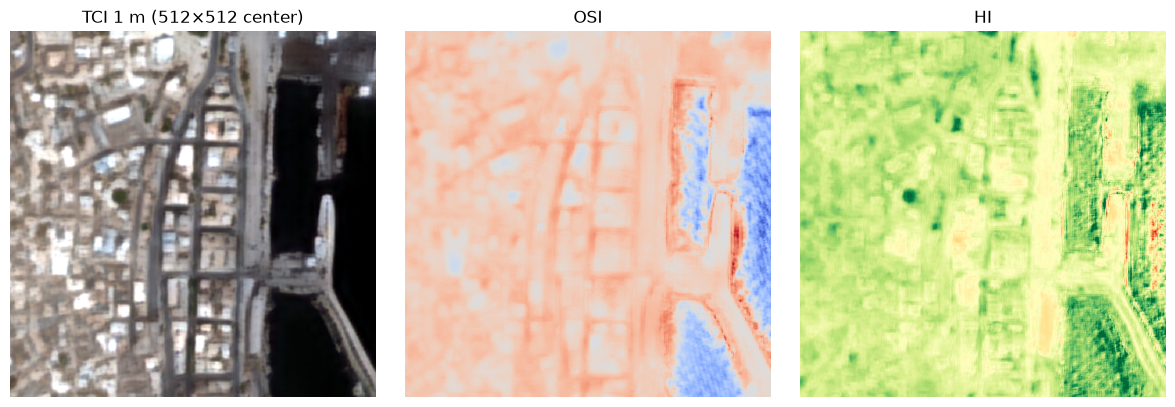

In [2]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
if MS and MS.exists():
    w=512; y0, x0 = 2048-256, 2048-256
    with rasterio.open(MS) as s:
        dn=s.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)
        def stretch(b, lo=2, hi=98):
            l, h = np.percentile(b, (lo,hi))
            return np.clip((b-l)*(255/(h-l+1e-6)),0,255).astype(np.uint8)
        rgb=np.dstack([stretch(dn[2]), stretch(dn[1]), stretch(dn[0])])
    with rasterio.open(oil_dir/"osi.tiff") as s:
        osi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    with rasterio.open(oil_dir/"hi.tiff") as s:
        hi=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(rgb); ax[0].set_title("TCI 1 m (512×512 center)"); ax[0].axis("off")
    ax[1].imshow(osi, cmap="coolwarm", vmin=-0.5, vmax=0.5); ax[1].set_title("OSI"); ax[1].axis("off")
    ax[2].imshow(hi, cmap="RdYlGn", vmin=-0.2, vmax=0.2); ax[2].set_title("HI"); ax[2].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Need MS.tif + oil/*.tiff")


## 2. Water / glint mask (critical before thresholding)

water 20.1%  cloud 2.6%  glint 77.1% (on window)


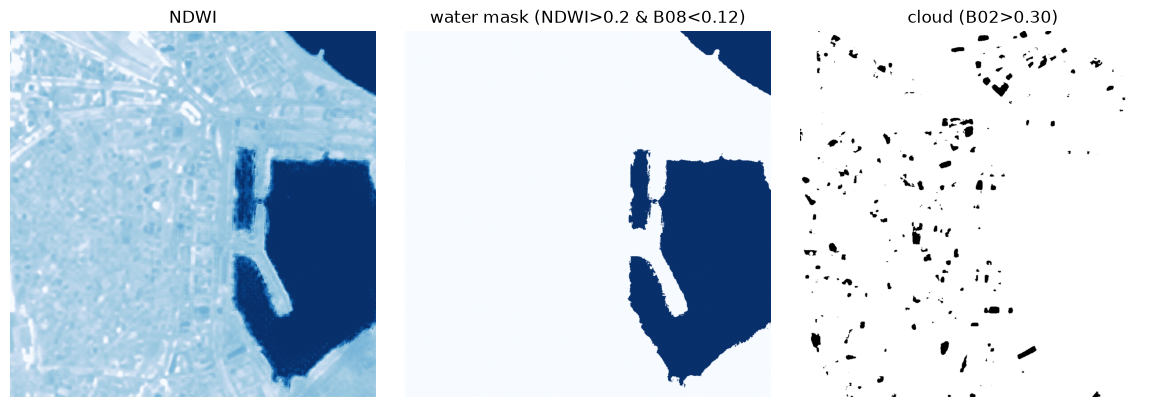

In [3]:
import rasterio, numpy as np, matplotlib.pyplot as plt
if MS and MS.exists():
    with rasterio.open(MS) as s:
        dn=s.read().astype(float)/10000
        b02,b03,b04,b08 = dn[0], dn[1], dn[2], dn[3]
        ndwi=np.where((b03+b08)==0, np.nan, (b03-b08)/(b03+b08))
        # use a 1024 window for display
        w=1024; y0,x0=2048-512,2048-512
        ndwi_w=ndwi[y0:y0+w, x0:x0+w]; b08_w=b08[y0:y0+w, x0:x0+w]; b02_w=b02[y0:y0+w, x0:x0+w]
        water=(ndwi_w>0.2)&(b08_w<0.12)&(b02_w<0.30)&np.isfinite(ndwi_w)
        cloud=b02_w>0.30
        print(f"water {water.mean():.1%}  cloud {cloud.mean():.1%}  glint {(b08_w>=0.12).mean():.1%} (on window)")
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(ndwi_w, cmap="Blues", vmin=-0.5, vmax=0.5); plt.title("NDWI"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(water, cmap="Blues"); plt.title("water mask (NDWI>0.2 & B08<0.12)"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(cloud, cmap="Greys"); plt.title("cloud (B02>0.30)"); plt.axis("off")
        plt.tight_layout(); plt.show()


## 3. Histograms — calibrate your threshold per scene
Do not use global thresholds blindly. Plot OSI/HI/FOI on water vs land, then pick the cut.

/tmp/ipykernel_111155/1640507058.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
/tmp/ipykernel_111155/1640507058.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
/tmp/ipykernel_111155/1640507058.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)


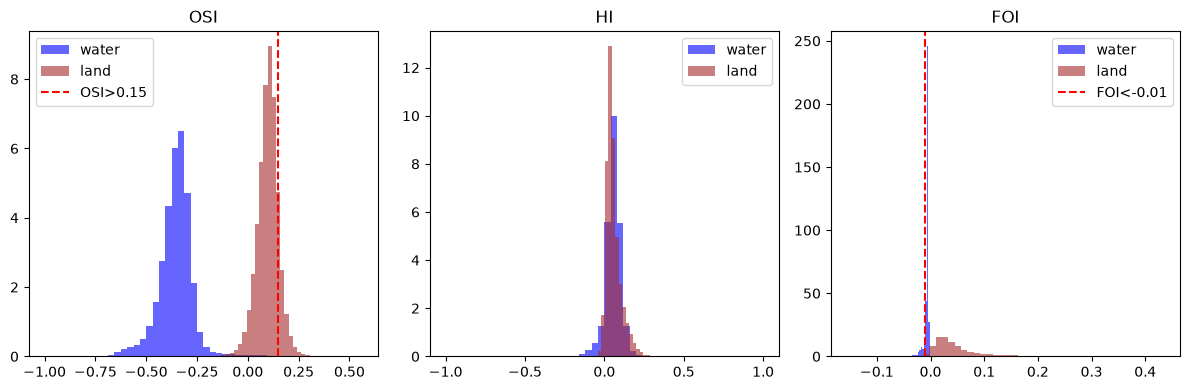

OSI on water: mean -0.355 p95 -0.251  land mean 0.099
FOI on water: mean -0.007  HI on water mean 0.056


In [4]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
if MS and MS.exists():
    with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
    with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
    with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
    with rasterio.open(MS) as s:
        dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
        land=~water & np.isfinite(ndwi)
    plt.figure(figsize=(12,4))
    for i, (name, arr) in enumerate([("OSI",osi), ("HI",hi), ("FOI",foi)]):
        plt.subplot(1,3,i+1)
        plt.hist(arr[water&np.isfinite(arr)].ravel(), bins=50, alpha=0.6, label="water", color="blue", density=True)
        plt.hist(arr[land&np.isfinite(arr)].ravel(), bins=50, alpha=0.6, label="land", color="brown", density=True)
        if name=="OSI": plt.axvline(0.15, color="red", ls="--", label="OSI>0.15")
        if name=="FOI": plt.axvline(-0.01, color="red", ls="--", label="FOI<-0.01")
        plt.title(name); plt.legend()
    plt.tight_layout(); plt.show()
    print(f"OSI on water: mean {np.nanmean(osi[water]):.3f} p95 {np.nanpercentile(osi[water],95):.3f}  land mean {np.nanmean(osi[land]):.3f}")
    print(f"FOI on water: mean {np.nanmean(foi[water]):.3f}  HI on water mean {np.nanmean(hi[water]):.3f}")


## 4. Triple test — high-confidence oil (interactive if ipywidgets available)

In [5]:
import rasterio, numpy as np, matplotlib.pyplot as plt
try:
    import ipywidgets as widgets
    from IPython.display import display
    has_widgets=True
except ImportError:
    has_widgets=False
    print("ipywidgets not installed — using static thresholds")
def render(osi_thr=0.15, hi_thr=0.03, foi_thr=-0.01):
    with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
    with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
    with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
    with rasterio.open(MS) as s:
        dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
    mask = water & (osi>osi_thr) & (foi<foi_thr) & (hi>hi_thr)
    print(f"high-conf oil on water: {mask.sum()} px ({mask.sum()/water.sum():.4%} of water)")
    plt.figure(figsize=(6,6)); plt.imshow(mask, cmap="Reds"); plt.title(f"oil mask OSI>{osi_thr} & FOI<{foi_thr} & HI>{hi_thr}"); plt.axis("off"); plt.show()
if has_widgets:
    widgets.interact(render, osi_thr=widgets.FloatSlider(value=0.15, min=0.0, max=0.4, step=0.02), hi_thr=widgets.FloatSlider(value=0.03, min=0.0, max=0.1, step=0.01), foi_thr=widgets.FloatSlider(value=-0.01, min=-0.03, max=0.0, step=0.005))
else:
    render()


interactive(children=(FloatSlider(value=0.15, description='osi_thr', max=0.4, step=0.02), FloatSlider(value=0.…

## 5. Scatter — HI vs OSI (water only, oil is top-right)

/tmp/ipykernel_111155/3096914519.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
/tmp/ipykernel_111155/3096914519.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)


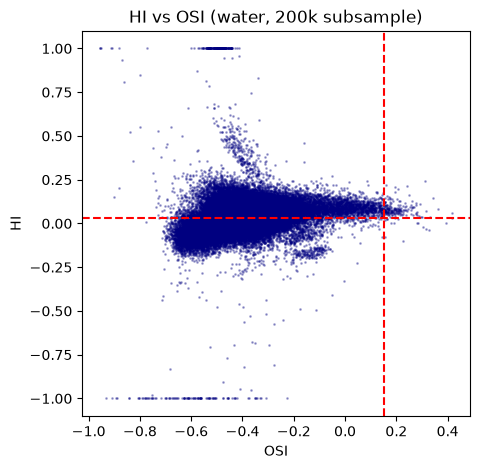

In [6]:
import rasterio, numpy as np, matplotlib.pyplot as plt
with rasterio.open(oil_dir/"osi.tiff") as s: osi=s.read(1)
with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
with rasterio.open(MS) as s:
    dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
m=water & np.isfinite(osi) & np.isfinite(hi)
# subsample for speed
y, x = np.where(m)
rng=np.random.default_rng(0); idx=rng.choice(len(y), size=min(200000, len(y)), replace=False)
plt.figure(figsize=(5,5)); plt.scatter(osi[y[idx], x[idx]], hi[y[idx], x[idx]], s=1, alpha=0.3, c="navy"); plt.axvline(0.15, color="red", ls="--"); plt.axhline(0.03, color="red", ls="--"); plt.xlabel("OSI"); plt.ylabel("HI"); plt.title("HI vs OSI (water, 200k subsample)"); plt.show()


## 6. Export — binary oil mask + GeoJSON bounds


In [7]:
import rasterio, numpy as np
from pathlib import Path
out = run_dir / "indices" / "oil" / "oil_mask.tiff"
with rasterio.open(oil_dir/"osi.tiff") as s:
    osi=s.read(1); profile=s.profile
with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)
with rasterio.open(MS) as s:
    dn=s.read().astype(float)/10000; ndwi=np.where((dn[1]+dn[3])==0, np.nan, (dn[1]-dn[3])/(dn[1]+dn[3])); water=(ndwi>0.2)&(dn[3]<0.12)
mask = (water & (osi>0.15) & (foi<-0.01) & (hi>0.03)).astype(np.uint8)
profile.update(dtype="uint8", nodata=255, compress=None)
try:
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(mask,1); dst.set_band_description(1,"oil mask triple test"); dst.update_tags(MASK="OSI>0.15 & FOI<-0.01 & HI>0.03 on water")
    print(f"wrote {out}  {int(mask.sum())} oil px")
except Exception as e:
    fallback=Path("/tmp/oil_mask.tiff")
    with rasterio.open(fallback, "w", **profile) as dst:
        dst.write(mask,1)
    print(f"Permission denied on {out}, wrote fallback {fallback}: {e}")


/tmp/ipykernel_111155/1210215392.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  osi=s.read(1); profile=s.profile
/tmp/ipykernel_111155/1210215392.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"hi.tiff") as s: hi=s.read(1)
/tmp/ipykernel_111155/1210215392.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  with rasterio.open(oil_dir/"foi.tiff") as s: foi=s.read(1)


wrote /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8/indices/oil/oil_mask.tiff  1042 oil px
